# i21-1707_DEEP_LEARNING_ASSIGNMENT_1


In [ ]:
import numpy as np
import glob

import os

ANN_PATH = "Dataset/Dataset/Dataset/annotations"




exp_files = sorted(glob.glob(os.path.join(ANN_PATH, "*_exp.npy")))
val_files = sorted(glob.glob(os.path.join(ANN_PATH, "*_val.npy")))
aro_files = sorted(glob.glob(os.path.join(ANN_PATH, "*_aro.npy")))


total_exp, total_val, total_aro = 0, 0, 0




for ef, vf, af in zip(exp_files, val_files, aro_files):
    exp = np.load(ef, allow_pickle=True)
    val = np.load(vf, allow_pickle=True)
    aro = np.load(af, allow_pickle=True)




    total_exp += exp.size
    total_val += val.size
    total_aro += aro.size



print("Total expression labels:", total_exp)
print("Total valence labels:", total_val)
print("Total arousal labels:", total_aro)


Total expression labels: 3999
Total valence labels: 3999
Total arousal labels: 3999


In [ ]:
import os
import glob

ANN_PATH = "Dataset/Dataset/Dataset/annotations"




all_npy = sorted(glob.glob(os.path.join(ANN_PATH, "*.npy")))
print("Total .npy files:", len(all_npy))




exp_files = [f for f in all_npy if "_exp.npy" in f]
val_files = [f for f in all_npy if "_val.npy" in f]
aro_files = [f for f in all_npy if "_aro.npy" in f]
lnd_files = [f for f in all_npy if "_lnd.npy" in f]




print("Expression files:", len(exp_files))
print("Valence files:", len(val_files))
print("Arousal files:", len(aro_files))
print("Landmark files:", len(lnd_files))





print("\nSample files:")
print("EXP:", exp_files[:5])
print("VAL:", val_files[:5])
print("ARO:", aro_files[:5])
print("LND:", lnd_files[:5])


Total .npy files: 15996
Expression files: 3999
Valence files: 3999
Arousal files: 3999
Landmark files: 3999

Sample files:
EXP: ['Dataset/Dataset/Dataset/annotations/0_exp.npy', 'Dataset/Dataset/Dataset/annotations/1001_exp.npy', 'Dataset/Dataset/Dataset/annotations/1002_exp.npy', 'Dataset/Dataset/Dataset/annotations/1003_exp.npy', 'Dataset/Dataset/Dataset/annotations/1007_exp.npy']
VAL: ['Dataset/Dataset/Dataset/annotations/0_val.npy', 'Dataset/Dataset/Dataset/annotations/1001_val.npy', 'Dataset/Dataset/Dataset/annotations/1002_val.npy', 'Dataset/Dataset/Dataset/annotations/1003_val.npy', 'Dataset/Dataset/Dataset/annotations/1007_val.npy']
ARO: ['Dataset/Dataset/Dataset/annotations/0_aro.npy', 'Dataset/Dataset/Dataset/annotations/1001_aro.npy', 'Dataset/Dataset/Dataset/annotations/1002_aro.npy', 'Dataset/Dataset/Dataset/annotations/1003_aro.npy', 'Dataset/Dataset/Dataset/annotations/1007_aro.npy']
LND: ['Dataset/Dataset/Dataset/annotations/0_lnd.npy', 'Dataset/Dataset/Dataset/annotati

In [ ]:
import os
import numpy as np
import glob
import pandas as pd




ANN_PATH = "Dataset/Dataset/Dataset/annotations"
IMG_PATH = "Dataset/Dataset/Dataset/images"




exp_files = sorted(glob.glob(os.path.join(ANN_PATH, "*_exp.npy")))
val_files = sorted(glob.glob(os.path.join(ANN_PATH, "*_val.npy")))
aro_files = sorted(glob.glob(os.path.join(ANN_PATH, "*_aro.npy")))



all_exp, all_val, all_aro = [], [], []




for ef, vf, af in zip(exp_files, val_files, aro_files):
    exp = np.load(ef, allow_pickle=True)
    val = np.load(vf, allow_pickle=True)
    aro = np.load(af, allow_pickle=True)

    
    
    
    if exp.shape == ():
        exp = np.array([exp.item()])
    if val.shape == ():
        val = np.array([val.item()])
    if aro.shape == ():
        aro = np.array([aro.item()])



    print(f"{ef}: {exp.shape}, {vf}: {val.shape}, {af}: {aro.shape}")  # debug



    all_exp.append(exp)
    all_val.append(val)
    all_aro.append(aro)

exp = np.concatenate(all_exp, axis=0)
val = np.concatenate(all_val, axis=0)
aro = np.concatenate(all_aro, axis=0)

\

image_ids = np.arange(len(exp))
image_paths = [os.path.join(IMG_PATH, f"{i}.jpg") for i in image_ids]




df = pd.DataFrame({
    "image_path": image_paths,
    "expression": exp,
    "valence": val,
    "arousal": aro
})



print("Total samples:", len(df))
print(df.head())


Dataset/Dataset/Dataset/annotations/0_exp.npy: (1,), Dataset/Dataset/Dataset/annotations/0_val.npy: (1,), Dataset/Dataset/Dataset/annotations/0_aro.npy: (1,)
Dataset/Dataset/Dataset/annotations/1001_exp.npy: (1,), Dataset/Dataset/Dataset/annotations/1001_val.npy: (1,), Dataset/Dataset/Dataset/annotations/1001_aro.npy: (1,)
Dataset/Dataset/Dataset/annotations/1002_exp.npy: (1,), Dataset/Dataset/Dataset/annotations/1002_val.npy: (1,), Dataset/Dataset/Dataset/annotations/1002_aro.npy: (1,)
Dataset/Dataset/Dataset/annotations/1003_exp.npy: (1,), Dataset/Dataset/Dataset/annotations/1003_val.npy: (1,), Dataset/Dataset/Dataset/annotations/1003_aro.npy: (1,)
Dataset/Dataset/Dataset/annotations/1007_exp.npy: (1,), Dataset/Dataset/Dataset/annotations/1007_val.npy: (1,), Dataset/Dataset/Dataset/annotations/1007_aro.npy: (1,)
Dataset/Dataset/Dataset/annotations/1008_exp.npy: (1,), Dataset/Dataset/Dataset/annotations/1008_val.npy: (1,), Dataset/Dataset/Dataset/annotations/1008_aro.npy: (1,)
Dataset

# Train/Validation Split

In [ ]:
from sklearn.model_selection import train_test_split




train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["expression"],  # keep expression class balance
    random_state=42
)


print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


Train samples: 3399
Val samples: 600


In [ ]:
import os
import numpy as np
import pandas as pd 
from glob import glob




IMG_PATH = "Dataset/Dataset/Dataset/images"
ANN_PATH = "Dataset/Dataset/Dataset/annotations"




all_data = []




exp_files = sorted(glob(os.path.join(ANN_PATH, "*_exp.npy")))




for ef in exp_files:
    base = os.path.basename(ef).replace("_exp.npy", "")
    img_file = os.path.join(IMG_PATH, f"{base}.jpg")
    val_file = os.path.join(ANN_PATH, f"{base}_val.npy")
    aro_file = os.path.join(ANN_PATH, f"{base}_aro.npy")



    if os.path.exists(img_file):  
        
        exp = np.load(ef).item()
        val = np.load(val_file).item()
        aro = np.load(aro_file).item()
        all_data.append([img_file, int(exp), float(val), float(aro)])

df = pd.DataFrame(all_data, columns=["image_path", "expression", "valence", "arousal"])

print(" Dataset built successfully")
print("Total valid samples:", len(df))
print(df.head())


 Dataset built successfully
Total valid samples: 3999
                                image_path  expression   valence   arousal
0     Dataset/Dataset/Dataset/images/0.jpg           0 -0.176846 -0.077640
1  Dataset/Dataset/Dataset/images/1001.jpg           0 -0.135501  0.004839
2  Dataset/Dataset/Dataset/images/1002.jpg           4 -0.114510  0.857748
3  Dataset/Dataset/Dataset/images/1003.jpg           5 -0.642857  0.484127
4  Dataset/Dataset/Dataset/images/1007.jpg           2 -0.796971 -0.229129


# train/test

In [ ]:
from sklearn.model_selection import train_test_split




train_df, val_df = train_test_split(
    df,
    test_size=0.15,
    stratify=df["expression"],
    random_state=42
)



print("Train samples:", len(train_df))
print("Val samples:", len(val_df))


Train samples: 3399
Val samples: 600


# TensorFlow Dataset Pipeline

In [ ]:
import tensorflow as tf



IMG_SIZE = 224
BATCH_SIZE = 32
AUTOTUNE = tf.data.AUTOTUNE





def preprocess(img_path, expr, val, aro):
    img = tf.io.read_file(img_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0

    expr = tf.cast(expr, tf.int32)
    expr = tf.one_hot(expr, depth=8)





    va = tf.stack([val, aro])
    return img, {"expression": expr, "va": va}





def augment(img, labels):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, 0.1)
    img = tf.image.random_contrast(img, 0.9, 1.1)
    return img, labels







def make_dataset(df_in, training=True):
    ds = tf.data.Dataset.from_tensor_slices((
        df_in["image_path"].values,
        df_in["expression"].values.astype("int32"),
        df_in["valence"].values.astype("float32"),
        df_in["arousal"].values.astype("float32")
    ))
    
    ds = ds.map(preprocess, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.map(augment, num_parallel_calls=AUTOTUNE)
        ds = ds.shuffle(buffer_size=len(df_in), seed=42)
    ds = ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)
    return ds



train_ds = make_dataset(train_df, training=True)
val_ds = make_dataset(val_df, training=False)


for imgs, labels in train_ds.take(1):
    print("Batch images:", imgs.shape)
    print("Batch expr:", labels["expression"].shape)
    print("Batch va:", labels["va"].shape)
    break


Batch images: (32, 224, 224, 3)
Batch expr: (32, 8)
Batch va: (32, 2)


# resnet

In [ ]:
from tensorflow.keras import layers, models, applications, optimizers, callbacks



def build_multitask_model(input_shape=(224,224,3)):
    base = applications.ResNet50(include_top=False, weights="imagenet", input_shape=input_shape)
    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.4)(x)

 
 
 
    cls = layers.Dense(256, activation="relu")(x)
    cls = layers.Dropout(0.3)(cls)
    cls_out = layers.Dense(8, activation="softmax", name="expression")(cls)



    reg = layers.Dense(128, activation="relu")(x)
    reg_out = layers.Dense(2, activation="tanh", name="va")(reg)

    return models.Model(inputs=base.input, outputs=[cls_out, reg_out])



model = build_multitask_model()



model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss={"expression": "categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 1.0, "va": 0.5},
    metrics={"expression": ["accuracy"]}
)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 230, 230,  │          0 │ input_layer[0][0] │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 112, 112,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 112, 112,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 112, 112,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 114, 114,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 56, 56,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 56, 56,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 56, 56,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 56, 56,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 56, 56,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 56, 56,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 56, 56,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 56, 56,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 56, 56,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 56, 56,    │      1,024 │ conv2_block1_3_c

 Total params: 24,376,842 (92.99 MB)

 Trainable params: 24,323,722 (92.79 MB)

 Non-trainable params: 53,120 (207.50 KB)

In [ ]:
import os
from datetime import datetime



OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
now = datetime.now().strftime("%Y%m%d-%H%M%S")

ckpt_path = os.path.join(OUTPUT_DIR, f"best_model_{now}.h5")

cb = [
    
    callbacks.ModelCheckpoint(
        ckpt_path,
        monitor="val_expression_accuracy",
        save_best_only=True,
        mode="max",  # ✅ keep best when accuracy is highest
        verbose=1
    ),
    
    callbacks.ReduceLROnPlateau(
        monitor="val_expression_accuracy",
        factor=0.5,
        patience=3,
        mode="max",   # ✅ tell it to maximize accuracy
        verbose=1
    ),
    
    callbacks.EarlyStopping(
        monitor="val_expression_accuracy",
        patience=7,
        restore_best_weights=True,
        mode="max",   # ✅ stop when accuracy stops improving
        verbose=1
    )
]




history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=23,
    callbacks=cb
)


Epoch 1/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 532ms/step - expression_accuracy: 0.1746 - expression_loss: 2.3250 - loss: 2.5372 - va_loss: 0.4245
Epoch 1: val_expression_accuracy improved from -inf to 0.12500, saving model to results/best_model_20250925-215033.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 142s 681ms/step - expression_accuracy: 0.1750 - expression_loss: 2.3231 - loss: 2.5349 - va_loss: 0.4237 - val_expression_accuracy: 0.1250 - val_expression_loss: 3.3933 - val_loss: 3.7368 - val_va_loss: 0.6901 - learning_rate: 1.0000e-04
Epoch 2/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 288ms/step - expression_accuracy: 0.3847 - expression_loss: 1.6278 - loss: 1.7229 - va_loss: 0.1902
Epoch 2: val_expression_accuracy did not improve from 0.12500
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 303ms/step - expression_accuracy: 0.3848 - expression_loss: 1.6276 - loss: 1.7226 - va_loss: 0.1901 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.5903 - val_loss: 2.8770 - val_va_loss: 0.5783 - learning_rate: 1.0000e-04
Epoch 3/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - expression_accuracy: 0.5255 - expression_loss: 1.3003 - loss: 1.3764 - va_loss: 0.1522
Epoch 3: val_expression_accuracy did not improve from 0.12500
107/107 ━━━━━━━━━━━━━━━━━━━━ 35s 305ms/step - expression_

107/107 ━━━━━━━━━━━━━━━━━━━━ 103s 941ms/step - expression_accuracy: 0.7724 - expression_loss: 0.7014 - loss: 0.7522 - va_loss: 0.1018 - val_expression_accuracy: 0.1683 - val_expression_loss: 2.5208 - val_loss: 2.6330 - val_va_loss: 0.2214 - learning_rate: 5.0000e-05
Epoch 6/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - expression_accuracy: 0.8701 - expression_loss: 0.4234 - loss: 0.4645 - va_loss: 0.0822
Epoch 6: val_expression_accuracy improved from 0.16833 to 0.25500, saving model to results/best_model_20250925-215033.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 76s 683ms/step - expression_accuracy: 0.8701 - expression_loss: 0.4233 - loss: 0.4644 - va_loss: 0.0822 - val_expression_accuracy: 0.2550 - val_expression_loss: 2.4167 - val_loss: 2.5123 - val_va_loss: 0.1971 - learning_rate: 5.0000e-05
Epoch 7/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - expression_accuracy: 0.9219 - expression_loss: 0.2519 - loss: 0.2876 - va_loss: 0.0712
Epoch 7: val_expression_accuracy improved from 0.25500 to 0.27500, saving model to results/best_model_20250925-215033.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 78s 695ms/step - expression_accuracy: 0.9219 - expression_loss: 0.2521 - loss: 0.2877 - va_loss: 0.0713 - val_expression_accuracy: 0.2750 - val_expression_loss: 2.4330 - val_loss: 2.5228 - val_va_loss: 0.2006 - learning_rate: 5.0000e-05
Epoch 8/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 292ms/step - expression_accuracy: 0.9441 - expression_loss: 0.1801 - loss: 0.2122 - va_loss: 0.0643
Epoch 8: val_expression_accuracy improved from 0.27500 to 0.34667, saving model to results/best_model_20250925-215033.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 55s 491ms/step - expression_accuracy: 0.9441 - expression_loss: 0.1802 - loss: 0.2123 - va_loss: 0.0643 - val_expression_accuracy: 0.3467 - val_expression_loss: 2.3412 - val_loss: 2.4249 - val_va_loss: 0.1829 - learning_rate: 5.0000e-05
Epoch 9/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 291ms/step - expression_accuracy: 0.9615 - expression_loss: 0.1246 - loss: 0.1548 - va_loss: 0.0605
Epoch 9: val_expression_accuracy improved from 0.34667 to 0.37833, saving model to results/best_model_20250925-215033.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 53s 478ms/step - expression_accuracy: 0.9615 - expression_loss: 0.1247 - loss: 0.1550 - va_loss: 0.0605 - val_expression_accuracy: 0.3783 - val_expression_loss: 2.4316 - val_loss: 2.5087 - val_va_loss: 0.1660 - learning_rate: 5.0000e-05
Epoch 10/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - expression_accuracy: 0.9752 - expression_loss: 0.0931 - loss: 0.1194 - va_loss: 0.0528
Epoch 10: val_expression_accuracy improved from 0.37833 to 0.41667, saving model to results/best_model_20250925-215033.h5


107/107 ━━━━━━━━━━━━━━━━━━━━ 79s 716ms/step - expression_accuracy: 0.9752 - expression_loss: 0.0932 - loss: 0.1195 - va_loss: 0.0528 - val_expression_accuracy: 0.4167 - val_expression_loss: 2.5464 - val_loss: 2.6223 - val_va_loss: 0.1439 - learning_rate: 5.0000e-05
Epoch 11/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - expression_accuracy: 0.9606 - expression_loss: 0.1293 - loss: 0.1557 - va_loss: 0.0528
Epoch 11: val_expression_accuracy did not improve from 0.41667
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 308ms/step - expression_accuracy: 0.9606 - expression_loss: 0.1292 - loss: 0.1556 - va_loss: 0.0528 - val_expression_accuracy: 0.4100 - val_expression_loss: 2.7410 - val_loss: 2.8170 - val_va_loss: 0.1466 - learning_rate: 5.0000e-05
Epoch 12/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - expression_accuracy: 0.9654 - expression_loss: 0.0941 - loss: 0.1199 - va_loss: 0.0515
Epoch 12: val_expression_accuracy improved from 0.41667 to 0.43167, saving model to results/best_model_20250925-21503

107/107 ━━━━━━━━━━━━━━━━━━━━ 111s 1s/step - expression_accuracy: 0.9655 - expression_loss: 0.0942 - loss: 0.1200 - va_loss: 0.0515 - val_expression_accuracy: 0.4317 - val_expression_loss: 2.6906 - val_loss: 2.7578 - val_va_loss: 0.1403 - learning_rate: 5.0000e-05
Epoch 13/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - expression_accuracy: 0.9783 - expression_loss: 0.0838 - loss: 0.1077 - va_loss: 0.0478
Epoch 13: val_expression_accuracy did not improve from 0.43167
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 308ms/step - expression_accuracy: 0.9783 - expression_loss: 0.0840 - loss: 0.1078 - va_loss: 0.0478 - val_expression_accuracy: 0.4167 - val_expression_loss: 2.8185 - val_loss: 2.8861 - val_va_loss: 0.1425 - learning_rate: 5.0000e-05
Epoch 14/23
107/107 ━━━━━━━━━━━━━━━━━━━━ 0s 289ms/step - expression_accuracy: 0.9827 - expression_loss: 0.0636 - loss: 0.0869 - va_loss: 0.0465
Epoch 14: val_expression_accuracy did not improve from 0.43167
107/107 ━━━━━━━━━━━━━━━━━━━━ 36s 305ms/step - expression

In [ ]:
# Evaluation & visualization setup
import numpy as np, matplotlib.pyplot as plt, os, json, random
import tensorflow as tf
from sklearn.metrics import (confusion_matrix, accuracy_score, f1_score,
                             cohen_kappa_score, roc_auc_score, precision_recall_curve,
                             auc, classification_report)
from scipy.stats import pearsonr



# Output folder
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)


In [ ]:

def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))



def ccc(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    def ccc1(a,b):
        
        
        ma, mb = a.mean(), b.mean()
        va, vb = a.var(), b.var()
        cov = np.mean((a-ma)*(b-mb))
        return (2*cov) / (va + vb + (ma-mb)**2 + 1e-8)
    if y_true.ndim==1: return ccc1(y_true, y_pred)
    return np.array([ccc1(y_true[:,i], y_pred[:,i]) for i in range(y_true.shape[1])])




def sagr(y_true, y_pred):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    if y_true.ndim==1: return np.mean(np.sign(y_true)==np.sign(y_pred))
    return np.array([np.mean(np.sign(y_true[:,i])==np.sign(y_pred[:,i])) for i in range(y_true.shape[1])])


In [ ]:
import pandas as pd
import numpy as np
import glob, os

# Paths
IMG_DIR = "Dataset/Dataset/Dataset/images"
ANNO_DIR = "Dataset/Dataset/Dataset/annotations"

# Collect samples
all_data = []


exp_files = sorted(glob.glob(os.path.join(ANNO_DIR, "*_exp.npy")))



for ef in exp_files:
    
    
    
    base = os.path.basename(ef).replace("_exp.npy", "")
    img_file = os.path.join(IMG_DIR, f"{base}.jpg")
    val_file = os.path.join(ANNO_DIR, f"{base}_val.npy")
    aro_file = os.path.join(ANNO_DIR, f"{base}_aro.npy")




    if os.path.exists(img_file):  
        exp = np.load(ef).item()
        val = np.load(val_file).item()
        aro = np.load(aro_file).item()
        all_data.append([img_file, int(exp), float(val), float(aro)])



df = pd.DataFrame(all_data, columns=["image_path", "expression", "valence", "arousal"])




from sklearn.model_selection import train_test_split
train_df, val_df = train_test_split(df, test_size=0.15, stratify=df["expression"], random_state=42)





print("Dataset built successfully")

print("Total valid samples:", len(df))
print(df.head())
print("Train samples:", len(train_df))
print("Val samples:", len(val_df))

Dataset built successfully
Total valid samples: 3999
                                image_path  expression   valence   arousal
0     Dataset/Dataset/Dataset/images/0.jpg           0 -0.176846 -0.077640
1  Dataset/Dataset/Dataset/images/1001.jpg           0 -0.135501  0.004839
2  Dataset/Dataset/Dataset/images/1002.jpg           4 -0.114510  0.857748
3  Dataset/Dataset/Dataset/images/1003.jpg           5 -0.642857  0.484127
4  Dataset/Dataset/Dataset/images/1007.jpg           2 -0.796971 -0.229129
Train samples: 3399
Val samples: 600


In [ ]:


val_paths = val_df['image_path'].values
y_true_expr = val_df['expression'].astype(int).values

y_true_va = val_df[['valence','arousal']].values.astype(float)


print("Validation samples:", len(val_paths))

print("Expressions shape:", y_true_expr.shape)

print("VA shape:", y_true_va.shape)


Validation samples: 600
Expressions shape: (600,)
VA shape: (600, 2)


In [ ]:
from tensorflow.keras.models import load_model



best_model_path = "results/best_model_20250925-215033.h5"





model = load_model(best_model_path, compile=False)



print("✅ Model loaded for evaluation:", best_model_path)


✅ Model loaded for evaluation: results/best_model_20250925-215033.h5


In [ ]:
pred_probs, pred_va = predict_on_paths(model, val_paths, batch_size=32)
pred_expr = np.argmax(pred_probs, axis=1)




print("Predicted classes shape:", pred_expr.shape)
print("Predicted VA shape:", pred_va.shape)


Predicted classes shape: (600,)
Predicted VA shape: (600, 2)


In [ ]:
from sklearn.metrics import accuracy_score, f1_score, cohen_kappa_score, confusion_matrix, classification_report, roc_auc_score, precision_recall_curve, auc
from scipy.stats import pearsonr
import numpy as np




acc = accuracy_score(y_true_expr, pred_expr)
f1m = f1_score(y_true_expr, pred_expr, average='macro')


kappa = cohen_kappa_score(y_true_expr, pred_expr)
conf = confusion_matrix(y_true_expr, pred_expr)




print("Classification Metrics:")
print("Accuracy:", acc)
print("F1-macro:", f1m)


print("Cohen Kappa:", kappa)
print("\nConfusion Matrix:\n", conf)
print("\nClassification Report:\n", classification_report(y_true_expr, pred_expr))



try:
    
    
    
    aucs = roc_auc_score(tf.keras.utils.to_categorical(y_true_expr, 8), pred_probs, average='macro', multi_class='ovr')
    print("AUC-ROC (macro):", aucs)
except Exception as e:
    print("AUC-ROC skipped:", e)






try:
    
    
    pr_aucs = []
    y_true_bin = tf.keras.utils.to_categorical(y_true_expr, 8)
    for c in range(8):
        
        
        precision, recall, _ = precision_recall_curve(y_true_bin[:, c], pred_probs[:, c])
        pr_aucs.append(auc(recall, precision))
    print("AUC-PR (per-class):", pr_aucs)
    print("AUC-PR (macro):", np.mean(pr_aucs))
except Exception as e:
    print("AUC-PR skipped:", e)


def rmse(y_true, y_pred):
    return np.sqrt(np.mean((y_true - y_pred)**2, axis=0))

def ccc(y_true, y_pred):
    def ccc1(a,b):
        
        
        ma, mb = a.mean(), b.mean()
        va, vb = a.var(), b.var()
        cov = np.mean((a-ma)*(b-mb))
        return (2*cov) / (va + vb + (ma-mb)**2 + 1e-8)
    return np.array([ccc1(y_true[:,i], y_pred[:,i]) for i in range(y_true.shape[1])])



def sagr(y_true, y_pred):
    return np.array([np.mean(np.sign(y_true[:,i]) == np.sign(y_pred[:,i])) for i in range(y_true.shape[1])])



mask = ~((y_true_va[:,0] == -2) | (y_true_va[:,1] == -2))
true_va_valid = y_true_va[mask]
pred_va_valid = pred_va[mask]





print("\nRegression Metrics (Valence, Arousal):")
print("RMSE:", rmse(true_va_valid, pred_va_valid))
print("CCC:", ccc(true_va_valid, pred_va_valid))
print("SAGR:", sagr(true_va_valid, pred_va_valid))
corrs = [pearsonr(true_va_valid[:,i], pred_va_valid[:,i])[0] for i in range(2)]
print("Pearson CORR:", corrs)


Classification Metrics:
Accuracy: 0.43166666666666664
F1-macro: 0.43200141666428826
Cohen Kappa: 0.3504761904761905

Confusion Matrix:
 [[24  3  8  5 10  6 15  4]
 [ 6 45  0  5  2  4  4  9]
 [11  5 21  3  9  9 16  1]
 [ 5  7  4 29 25  2  3  0]
 [ 6  0  4 10 45  2  7  1]
 [ 3  2  4  4  8 31 20  3]
 [ 9  2  2  5  9 11 34  3]
 [21  7  3  2  0  4  8 30]]

Classification Report:
               precision    recall  f1-score   support

           0       0.28      0.32      0.30        75
           1       0.63      0.60      0.62        75
           2       0.46      0.28      0.35        75
           3       0.46      0.39      0.42        75
           4       0.42      0.60      0.49        75
           5       0.45      0.41      0.43        75
           6       0.32      0.45      0.37        75
           7       0.59      0.40      0.48        75

    accuracy                           0.43       600
   macro avg       0.45      0.43      0.43       600
weighted avg       0.45   

In [2]:
import matplotlib.pyplot as plt


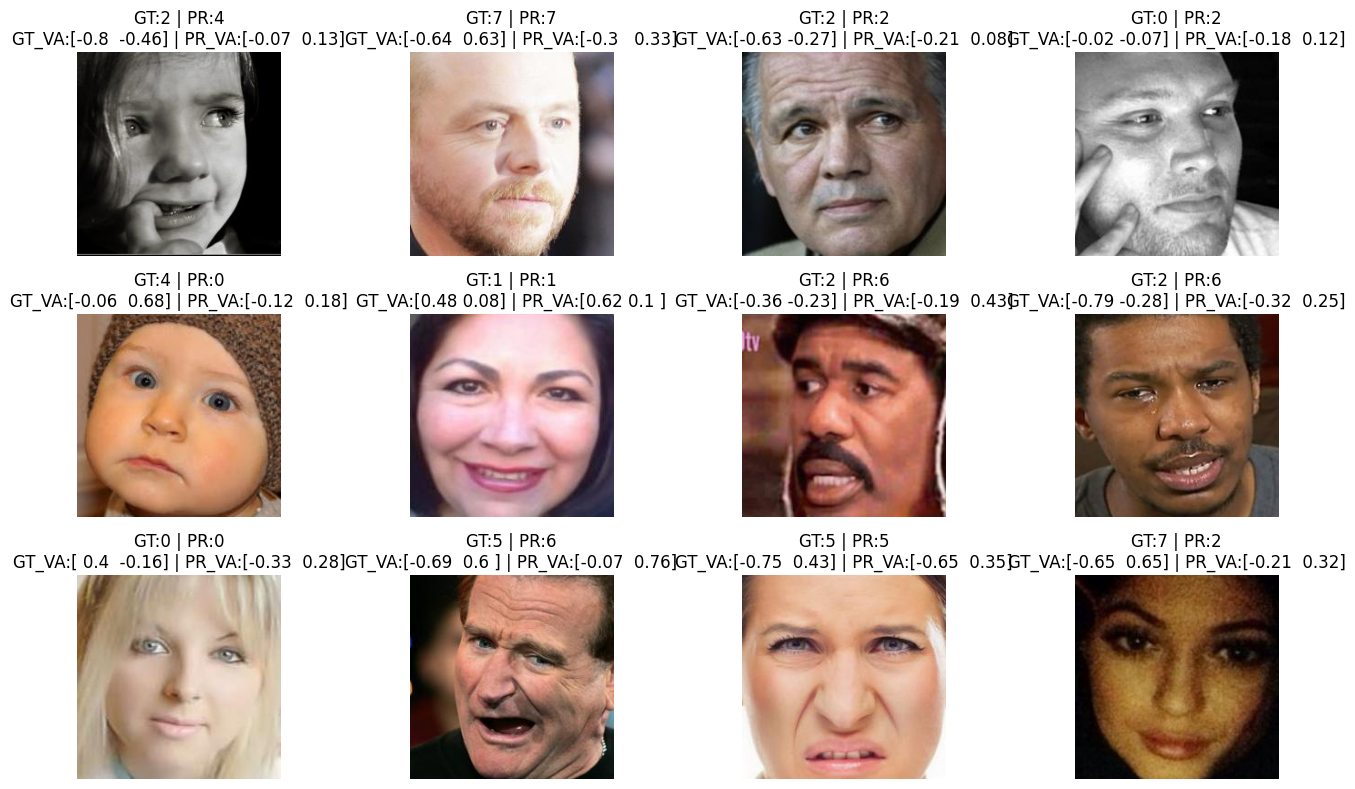

In [ ]:
import random

idxs = random.sample(range(len(val_paths)), 12)
plt.figure(figsize=(14,8))


for i, idx in enumerate(idxs):
    img = plt.imread(val_paths[idx])
    plt.subplot(3,4,i+1)
    plt.imshow(img)
    plt.axis('off')


    gt = y_true_expr[idx]
    pr = pred_expr[idx]
    gva = y_true_va[idx]
    pva = pred_va[idx]
    

    plt.title(f"GT:{gt} | PR:{pr}\nGT_VA:{np.round(gva,2)} | PR_VA:{np.round(pva,2)}")

plt.tight_layout()
plt.show()


# next model efficient net


In [ ]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

def preprocess_image(path, expr, va):
    img = tf.io.read_file(path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    img = tf.cast(img, tf.float32) / 255.0
    return img, {"expression": tf.one_hot(expr, 8), "va": va}



train_ds = (tf.data.Dataset.from_tensor_slices((train_df['image_path'].values,
                                                train_df['expression'].values,
                                                train_df[['valence','arousal']].values.astype('float32')))
            .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
            .shuffle(500)
            .batch(BATCH_SIZE)
            .prefetch(tf.data.AUTOTUNE))



val_ds = (tf.data.Dataset.from_tensor_slices((val_df['image_path'].values,
                                              val_df['expression'].values,
                                              val_df[['valence','arousal']].values.astype('float32')))
          .map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)
          .batch(BATCH_SIZE)
          .prefetch(tf.data.AUTOTUNE))





In [ ]:
from tensorflow.keras import callbacks
import os
from datetime import datetime

OUTPUT_DIR = "results"


os.makedirs(OUTPUT_DIR, exist_ok=True)

now = datetime.now().strftime("%Y%m%d-%H%M%S")


ckpt_path = os.path.join(OUTPUT_DIR, f"best_model_{now}.h5")


from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint


cb = [
    EarlyStopping(
        monitor="val_expression_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max"  
    ),
    
    ModelCheckpoint(
        filepath="results/best_model_20250925-222420.h5",
        monitor="val_expression_accuracy",
        save_best_only=True,
        mode="max"  # <--- explicitly specify mode
    )
]


In [ ]:
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input



def build_efficientnet_model(input_shape=(224,224,3)):
    
    
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = False  # freeze base for initial training



    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.4)(x)




    cls = layers.Dense(256, activation="relu")(x)
    cls = layers.Dropout(0.3)(cls)
    
    cls_out = layers.Dense(8, activation="softmax", name="expression")(cls)



    reg = layers.Dense(128, activation="relu")(x)
    reg_out = layers.Dense(2, activation="tanh", name="va")(reg)

    return models.Model(inputs=base.input, outputs=[cls_out, reg_out])


In [ ]:
efficient_model = build_efficientnet_model()

efficient_model.compile(
    
    optimizer=optimizers.Adam(1e-4),
    loss={"expression": "categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 1.0, "va": 0.5},
    metrics={"expression": ["accuracy"]}
)


In [33]:
train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds = val_ds.map(lambda x, y: (preprocess_input(x), y))


In [34]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

cb = [
    EarlyStopping(
        monitor="val_expression_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max"
    ),
    ModelCheckpoint(
        filepath="results/best_efficientnet_model.keras",
        monitor="val_expression_accuracy",
        save_best_only=True,
        mode="max"
    )
]


In [35]:
history = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15,
    callbacks=cb
)


Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 55s 285ms/step - expression_accuracy: 0.1388 - expression_loss: 2.1162 - loss: 2.2334 - va_loss: 0.2345 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.0834 - val_loss: 2.1755 - val_va_loss: 0.1841
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 45s 49ms/step - expression_accuracy: 0.1244 - expression_loss: 2.1064 - loss: 2.2038 - va_loss: 0.1948 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.0814 - val_loss: 2.1732 - val_va_loss: 0.1835
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 53ms/step - expression_accuracy: 0.1212 - expression_loss: 2.0982 - loss: 2.1930 - va_loss: 0.1895 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.0812 - val_loss: 2.1724 - val_va_loss: 0.1823
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 61ms/step - expression_accuracy: 0.1339 - expression_loss: 2.0953 - loss: 2.1891 - va_loss: 0.1875 - val_expression_accuracy: 0.1250 - val_expression_loss: 2.0801 - val_loss: 2.1712 - val_va_loss: 0.1819
Epoch 5/1

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import os
from datetime import datetime
import pandas as pd





IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 15
OUTPUT_DIR = "results"
os.makedirs(OUTPUT_DIR, exist_ok=True)
now = datetime.now().strftime("%Y%m%d-%H%M%S")





def preprocess_image(path, expr, va):
    
    img = tf.io.read_file(path)
    
    img = tf.image.decode_jpeg(img, channels=3)
    
    img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
    
    img = tf.cast(img, tf.float32)  
    
    return img, {"expression": tf.one_hot(expr, 8, dtype=tf.float32), "va": tf.cast(va, tf.float32)}




train_ds = tf.data.Dataset.from_tensor_slices((
    train_df['image_path'].values,
    train_df['expression'].values,
    train_df[['valence','arousal']].values.astype('float32')
)).map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)\
  .shuffle(500)\
  .batch(BATCH_SIZE)\
  .prefetch(tf.data.AUTOTUNE)




val_ds = tf.data.Dataset.from_tensor_slices((
    val_df['image_path'].values,
    val_df['expression'].values,
    val_df[['valence','arousal']].values.astype('float32')
)).map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)\
  .batch(BATCH_SIZE)\
  .prefetch(tf.data.AUTOTUNE)





train_ds = train_ds.map(lambda x, y: (preprocess_input(x), y))
val_ds   = val_ds.map(lambda x, y: (preprocess_input(x), y))






def build_efficientnet_model(input_shape=(224,224,3)):
    base = EfficientNetB0(include_top=False, weights="imagenet", input_shape=input_shape)
    base.trainable = False  # Freeze initially




    x = layers.GlobalAveragePooling2D()(base.output)
    x = layers.Dropout(0.3)(x)





    # Classification branch
    cls = layers.Dense(256, activation="relu")(x)
    cls = layers.Dropout(0.2)(cls)
    cls_out = layers.Dense(8, activation="softmax", name="expression")(cls)



    # Regression branch
    reg = layers.Dense(128, activation="relu")(x)
    reg_out = layers.Dense(2, activation="tanh", name="va")(reg)



    model = models.Model(inputs=base.input, outputs=[cls_out, reg_out])
    return model




efficient_model = build_efficientnet_model()



efficient_model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss={"expression": "categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 1.0, "va": 0.5},
    metrics={"expression": ["accuracy"]}
)




cb = [
    EarlyStopping(
        monitor="val_expression_accuracy",
        patience=5,
        restore_best_weights=True,
        mode="max"
    ),
    ModelCheckpoint(
        filepath=os.path.join(OUTPUT_DIR, f"best_efficientnet_model_{now}.keras"),
        monitor="val_expression_accuracy",
        save_best_only=True,
        mode="max"
    )
]

history = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=cb
)




efficient_model.trainable = True
for layer in efficient_model.layers[:-20]:  # Freeze all but last 20 layers
    layer.trainable = False




efficient_model.compile(
    optimizer=optimizers.Adam(1e-5),
    loss={"expression": "categorical_crossentropy", "va": "mse"},
    loss_weights={"expression": 1.0, "va": 0.5},
    metrics={"expression": ["accuracy"]}
)




history_finetune = efficient_model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10,
    callbacks=cb
)


Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 54s 277ms/step - expression_accuracy: 0.1386 - expression_loss: 2.1465 - loss: 2.2827 - va_loss: 0.2725 - val_expression_accuracy: 0.2217 - val_expression_loss: 2.0022 - val_loss: 2.0983 - val_va_loss: 0.1922
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 54ms/step - expression_accuracy: 0.2037 - expression_loss: 2.0321 - loss: 2.1394 - va_loss: 0.2146 - val_expression_accuracy: 0.2150 - val_expression_loss: 1.9608 - val_loss: 2.0516 - val_va_loss: 0.1816
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 6s 55ms/step - expression_accuracy: 0.2444 - expression_loss: 1.9517 - loss: 2.0482 - va_loss: 0.1930 - val_expression_accuracy: 0.2383 - val_expression_loss: 1.9327 - val_loss: 2.0240 - val_va_loss: 0.1820
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 60ms/step - expression_accuracy: 0.2559 - expression_loss: 1.9224 - loss: 2.0160 - va_loss: 0.1871 - val_expression_accuracy: 0.2417 - val_expression_loss: 1.9102 - val_loss: 1.9969 - val_va_loss: 0.1732
Epoch 5/15

In [39]:
efficient_model.save("results/final_efficientnet_model.keras")


In [40]:
results = efficient_model.evaluate(val_ds)
print(results)


19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 55ms/step - expression_accuracy: 0.3091 - expression_loss: 1.7972 - loss: 1.8828 - va_loss: 0.1711
[1.885307788848877, 1.8025999069213867, 0.1637556254863739, 0.3100000023841858]


In [ ]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix


y_true = np.concatenate([y['expression'].numpy() for x, y in val_ds])


y_true_labels = np.argmax(y_true, axis=1)

y_pred = np.argmax(np.concatenate([efficient_model.predict(x)[0] for x, y in val_ds]), axis=1)

print(classification_report(y_true_labels, y_pred))


print(confusion_matrix(y_true_labels, y_pred))


1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step
              precision    recall  f1-score   support

           0       0.31      0.31      0.31        75
           1       0.37      0.36      0.36        75
           2       0.24      0.23      0.23        75
           3       0.41      0.32      0.36        75
         

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_true_va = np.concatenate([y['va'].numpy() for x, y in val_ds])
y_pred_va = np.concatenate([efficient_model.predict(x)[1] for x, y in val_ds])


mse = mean_squared_error(y_true_va, y_pred_va)
mae = mean_absolute_error(y_true_va, y_pred_va)
r2 = r2_score(y_true_va, y_pred_va)

print("MSE:", mse)
print("MAE:", mae)
print("R2 Score:", r2)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
MSE: 0.16405870020389557
MAE: 0.33944594860076904
R2 Score: 0.08319631218910217


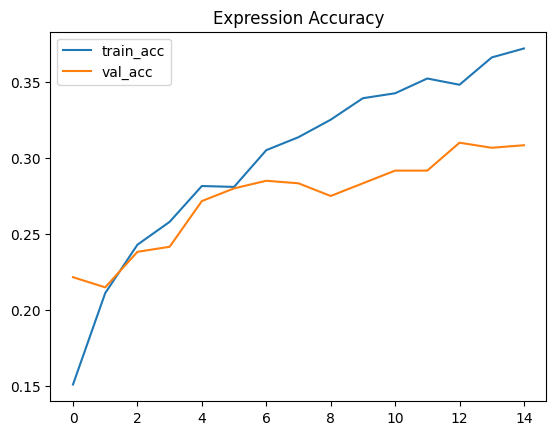

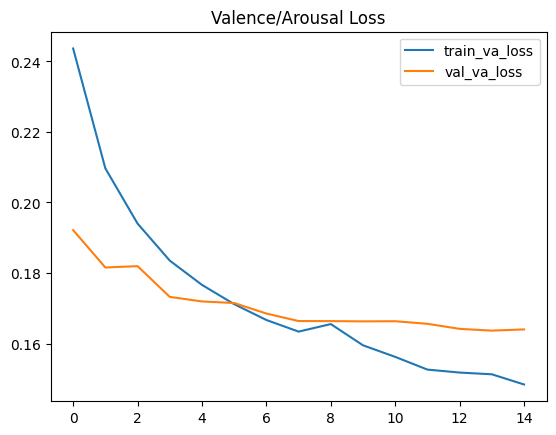

In [43]:
import matplotlib.pyplot as plt

# Classification
plt.plot(history.history['expression_accuracy'], label='train_acc')
plt.plot(history.history['val_expression_accuracy'], label='val_acc')
plt.title('Expression Accuracy')
plt.legend()
plt.show()

# Regression
plt.plot(history.history['va_loss'], label='train_va_loss')
plt.plot(history.history['val_va_loss'], label='val_va_loss')
plt.title('Valence/Arousal Loss')
plt.legend()
plt.show()


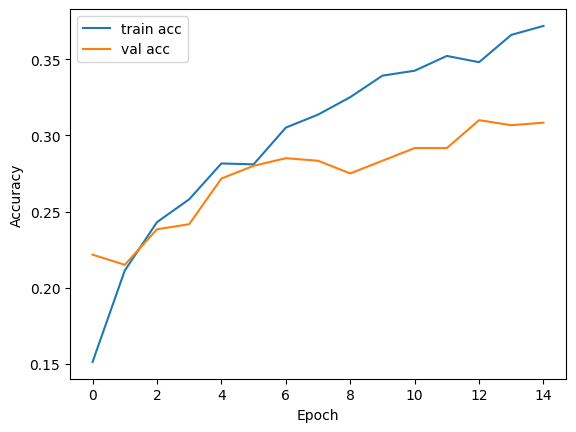

In [44]:
import matplotlib.pyplot as plt

plt.plot(history.history['expression_accuracy'], label='train acc')
plt.plot(history.history['val_expression_accuracy'], label='val acc')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [45]:
from google.colab import files
import shutil

# Zip the folder
shutil.make_archive("results_folder", 'zip', "results")

# Download the zip
files.download("results_folder.zip")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

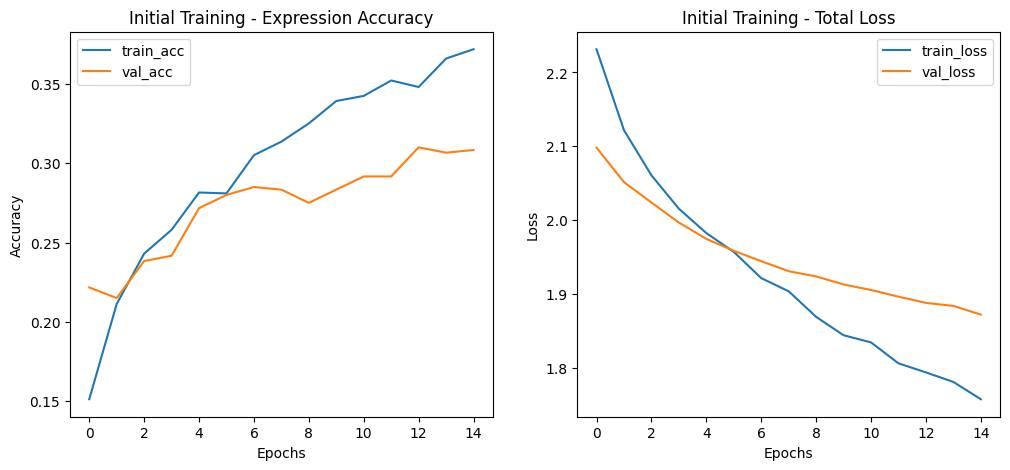

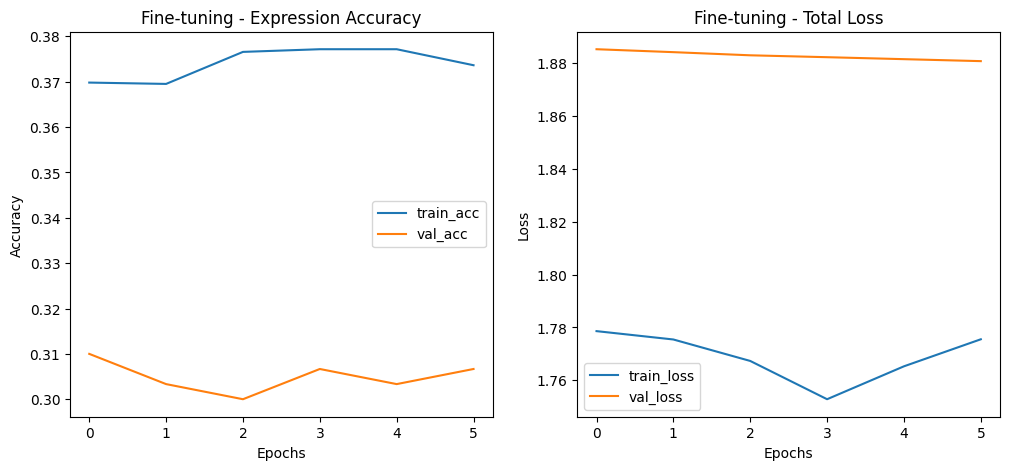

In [46]:
import matplotlib.pyplot as plt

def plot_training(history, title="Model Training"):
    # Classification accuracy
    plt.figure(figsize=(12,5))

    # Accuracy
    plt.subplot(1,2,1)
    plt.plot(history.history['expression_accuracy'], label='train_acc')
    plt.plot(history.history.get('val_expression_accuracy', []), label='val_acc')
    plt.title(f'{title} - Expression Accuracy')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()

    # Loss
    plt.subplot(1,2,2)
    plt.plot(history.history['loss'], label='train_loss')
    plt.plot(history.history.get('val_loss', []), label='val_loss')
    plt.title(f'{title} - Total Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()

    plt.show()

# Plot for initial training
plot_training(history, title="Initial Training")

# Plot for fine-tuning
plot_training(history_finetune, title="Fine-tuning")
